In [3]:
import sys
import os

# Añadimos la carpeta superior (la raíz del proyecto)
sys.path.append(os.path.abspath(os.path.join('..')))

,Variable,ADF_Stat,ADF_Crit5,KPSS_Pval,Diagnostico
0,btc,-3.683,-3.452,0.049,Inconcluso
1,nasdaq,-3.790,-3.450,0.100,Estacionaria (I0)
2,fed_rate,-2.862,-3.449,0.010,No Estacionaria (I1)
3,btc_vol,-5.369,-3.448,0.036,Inconcluso


                            OLS Regression Results                            
Dep. Variable:                    btc   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     288.7
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.66e-54
Time:                        23:24:30   Log-Likelihood:                -1275.0
No. Observations:                 122   AIC:                             2558.
Df Residuals:                     118   BIC:                             2569.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.359e+04   2753.771    -12.199      0.0

<Figure size 800x600 with 0 Axes>

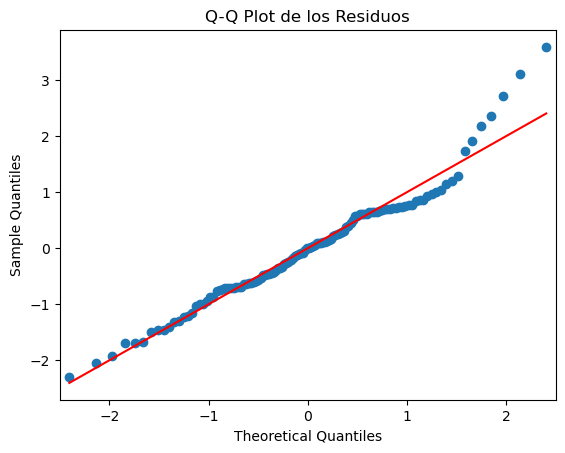

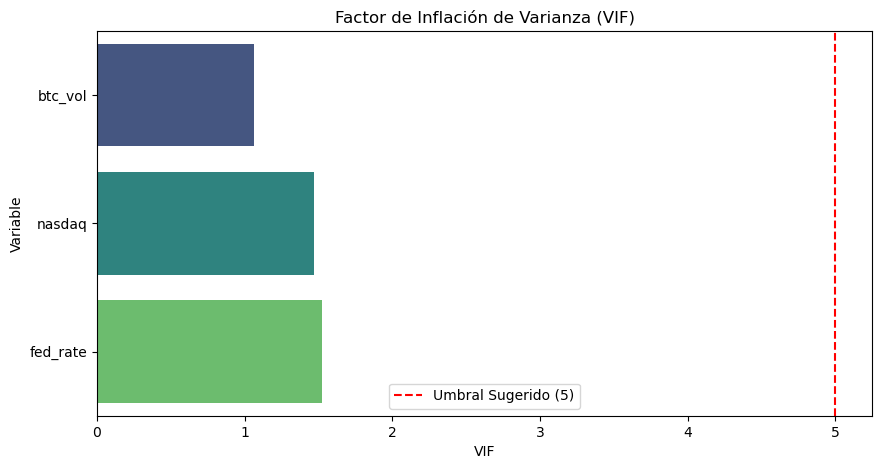

In [4]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
# Ignoramos tanto UserWarning como InterpolationWarning para tener una salida mas limpia
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=InterpolationWarning)

# Cargamos datos y limpiamos nulos
df = pd.read_csv('../data/bitcoin_nasdaq_extended_py.csv', index_col='Date', parse_dates=True)
df = df.dropna() 

# Pruebas de Estacionariedad
from src.statistical_tests import check_stationarity
vars_to_test = ['btc', 'nasdaq', 'fed_rate', 'btc_vol']
tabla_estac = check_stationarity(df, vars_to_test)
display(tabla_estac)

# Modelo OLS Preliminar
X = df[['nasdaq', 'fed_rate', 'btc_vol']]
X = sm.add_constant(X) # Añadimos la constante (por defecto no se incluye)
y = df['btc']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

# Diagnóstico de Residuos
from src.statistical_tests import residual_diagnostics 
from src.data_visualization import plot_residuals_qq, plot_vif

diag = residual_diagnostics(modelo)
print(f"\n--- TEST DE DIAGNÓSTICO ---")
print(f"P-valor Shapiro (Normalidad): {diag['Shapiro_Pval']:.4f}")
print(f"P-valor Breusch-Pagan (Homocedasticidad): {diag['BP_Pval']:.4f}")
print(f"Durbin-Watson (Autocorr): {diag['DW_Stat']:.4f}")

# 5. Visualización
plot_residuals_qq(modelo)
# Pasamos solo las columnas del modelo para un VIF real
plot_vif(df[['btc', 'nasdaq', 'fed_rate', 'btc_vol']], 'btc')